# 03 — Evaluation: LPIPS + Condition Accuracy
Computes both required metrics for all models and prints a comparison table.
Run this after `02_inference.ipynb` has populated the `outputs/` folders.

In [14]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q uv
    !uv pip install --system lpips torch torchvision pillow pandas
    from google.colab import drive
    drive.mount('/content/drive')

In [15]:
if IN_COLAB:
    BASE = '/content/drive/My Drive/CIS_5190_group_project'
else:
    BASE = '..'

MANIFEST_CSV = f"{BASE}/manifest.csv"
ALIGNED_DIR     = f'{BASE}/hf_dataset'
CLASSIFIER_CKPT = f'{BASE}/checkpoints/classifier_best.pt'

# Maps model name → (output folder, filename suffix)
# Comment out any model whose outputs don't exist yet
MODELS = {
    'SD Baseline':       (f'{BASE}/outputs/sd_baseline',     '_sd_baseline.jpg'),
    'InstructPix2Pix':   (f'{BASE}/outputs/instructpix2pix', '_ip2p.jpg'),
    'ControlNet':        (f'{BASE}/outputs/controlnet',      '_controlnet.jpg'),
    'ControlNet + LoRA': (f'{BASE}/outputs/controlnet_lora', '_controlnet_lora.jpg'),
}

In [16]:
# Construct our evaluation dataframe from "manifest.csv"
# Mimics the structure of lpips_eval_set.csv
import pandas as pd
from itertools import combinations
from pathlib import Path
import os

# Only keep ones that we've approved
mani_df = pd.read_csv(MANIFEST_CSV)
mani_df = mani_df[mani_df["status"] == "kept"]

# Read metadata as this has more consistent image paths
meta_df = pd.read_csv(os.path.join(ALIGNED_DIR, "metadata.csv"))
mani_df = mani_df.drop(columns=["caption"])

meta_df["fname"] = meta_df["file_name"].apply(lambda x: Path(x).name)

# HACK: manually added _aligned.jpg to end of file name
mani_df["fname"] = mani_df["file_name"].apply(lambda x: Path(x).stem) + "_aligned.jpg"

# Drop this file_name column, it's kinda inconsistent, prefer the metadata.csv file names
mani_df = mani_df.drop(columns=["file_name"])

# Merge to get the columns of manifest.csv with consistent file names of metadata.csv
mani_df = mani_df.merge(meta_df, on=["fname","location","time_of_day","weather","is_synthetic","split"], how="inner")
mani_df["anchor_file"] = "images/" + mani_df["anchor_file"].apply(lambda x: Path(x).stem) + "_aligned_aligned.jpg"

# Only keep reocrds in which the anchor name exists 
mani_df = mani_df[mani_df["anchor_file"].isin(mani_df["file_name"])]

# Do inference only on the validation sets
mani_df = mani_df[mani_df["split"] == "val"]

# Schema of eval_df
eval_df = {
    "src_name": [],
    "location": [],
    "src_tod": [],
    "src_weather": [],

    "src_anchor": [],

    "tgt_name": [],
    "tgt_tod": [],
    "tgt_weather": [],

    "split": [],
}

# Go through and construct dat thing
for location in mani_df["location"].unique():
    loc_df = mani_df[mani_df["location"] == location]
    num_photos = len(loc_df)


    if num_photos == 1:
        # Just pair the data with itself
        eval_df["split"].append(loc_df["split"].iloc[0])

        eval_df["src_name"].append(loc_df["file_name"].iloc[0])
        eval_df["tgt_name"].append(loc_df["file_name"].iloc[0])


        eval_df["src_weather"].append(loc_df["weather"].iloc[0])
        eval_df["tgt_weather"].append(loc_df["weather"].iloc[0])

        eval_df["src_tod"].append(loc_df["time_of_day"].iloc[0])
        eval_df["tgt_tod"].append(loc_df["time_of_day"].iloc[0])

        eval_df["src_anchor"].append(loc_df["anchor_file"].iloc[0])
        eval_df["location"].append(location)
    else:
        # For all pairings of conditions, generate a
        # row going from one condition to another
        all_pairs = combinations(list(range(num_photos)), 2)

        for idx1, idx2 in all_pairs:
            eval_df["split"].append(loc_df["split"].iloc[idx1])

            eval_df["src_name"].append(loc_df["file_name"].iloc[idx1])
            eval_df["tgt_name"].append(loc_df["file_name"].iloc[idx2])

            eval_df["src_weather"].append(loc_df["weather"].iloc[idx1])
            eval_df["tgt_weather"].append(loc_df["weather"].iloc[idx2])

            eval_df["src_tod"].append(loc_df["time_of_day"].iloc[idx1])
            eval_df["tgt_tod"].append(loc_df["time_of_day"].iloc[idx2])
            eval_df["location"].append(location)
            eval_df["src_anchor"].append(loc_df["anchor_file"].iloc[idx1])


eval_df = pd.DataFrame(eval_df)
eval_df.head()

,src_name,location,src_tod,src_weather,src_anchor,tgt_name,tgt_tod,tgt_weather,split
0,images/collegegreen_daytime_rainy_aligned_alig...,collegegreen,daytime,rainy,images/collegegreen_daytime_rainy_aligned_alig...,images/collegegreen_night_clear_aligned_aligne...,night,clear,val
1,images/harrison_daytime_clear_aligned_aligned.jpg,harrison,daytime,clear,images/harrison_daytime_clear_aligned_aligned.jpg,images/harrison_daytime_rainy_aligned_aligned.jpg,daytime,rainy,val
2,images/locust1_sunset_rainy_aligned_aligned.jpg,locust1,sunset,rainy,images/locust1_sunset_rainy_aligned_aligned.jpg,images/locust1_sunset_rainy_aligned_aligned.jpg,sunset,rainy,val
3,images/mt_daytime_rainy_aligned_aligned.jpg,mt,daytime,rainy,images/mt_daytime_rainy_aligned_aligned.jpg,images/mt_night_clear_aligned_aligned.jpg,night,clear,val
4,images/mt_daytime_rainy_aligned_aligned.jpg,mt,daytime,rainy,images/mt_daytime_rainy_aligned_aligned.jpg,images/mt_sunset_cloudy_aligned_aligned.jpg,sunset,cloudy,val


In [17]:
import os
import torch
import lpips
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

loss_fn = lpips.LPIPS(net='alex').to(device)

lpips_tf = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def compute_lpips(gt_path, gen_path):
    gt  = lpips_tf(Image.open(gt_path).convert('RGB')).unsqueeze(0).to(device)
    gen = lpips_tf(Image.open(gen_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        return loss_fn(gt, gen).item()

print('LPIPS ready.')

Device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ubuntu/image-style-transfer/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
LPIPS ready.


In [18]:
import sys
if IN_COLAB:
    import os
    if not os.path.exists('/content/image-style-transfer'):
        !git clone https://github.com/YOUR_ORG/image-style-transfer /content/image-style-transfer
    sys.path.insert(0, '/content/image-style-transfer')
else:
    sys.path.insert(0, os.path.join(BASE))

from scripts.train_classifier import DualHeadResNet, TOD_CLASSES, WX_CLASSES

clf_ckpt = torch.load(CLASSIFIER_CKPT, map_location=device)
classifier = DualHeadResNet().to(device)
classifier.load_state_dict(clf_ckpt['model_state_dict'])
classifier.eval()

clf_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def classify(img_path):
    img = clf_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        tod_logits, wx_logits = classifier(img)
    return TOD_CLASSES[tod_logits.argmax().item()], WX_CLASSES[wx_logits.argmax().item()]

print('Classifier loaded.')

Classifier loaded.


In [19]:
summary = []

for model_name, (out_dir, suffix) in MODELS.items():
    lpips_scores = []
    correct_tod = correct_wx = total = 0

    for _, row in eval_df.iterrows():
        stem     = os.path.splitext(os.path.basename(row['tgt_name']))[0]
        gen_path = os.path.join(out_dir, stem + suffix)
        gt_path  = os.path.join(ALIGNED_DIR, row['tgt_name'])

        if not os.path.exists(gen_path):
            continue

        lpips_scores.append(compute_lpips(gt_path, gen_path))
        pred_tod, pred_wx = classify(gen_path)
        correct_tod += int(pred_tod == row['tgt_tod'].lower())
        correct_wx  += int(pred_wx  == row['tgt_weather'].lower())
        total += 1

    if total == 0:
        print(f'[SKIP] {model_name} — no output files found')
        continue

    summary.append({
        'Model':           model_name,
        'LPIPS':         round(np.mean(lpips_scores), 4),
        'LPIPS std':       round(np.std(lpips_scores), 4),
        'ToD Acc':       round(correct_tod / total, 3),
        'Weather Acc':   round(correct_wx  / total, 3),
        'N':               total,
    })

results_df = pd.DataFrame(summary)
print(results_df.to_string(index=False))

            Model  LPIPS  LPIPS std  ToD Acc  Weather Acc  N
      SD Baseline 0.6230     0.0890    0.227        0.409 22
  InstructPix2Pix 0.6470     0.1639    0.773        0.182 22
       ControlNet 0.6272     0.0730    0.227        0.182 22
ControlNet + LoRA 0.6202     0.0756    0.364        0.409 22


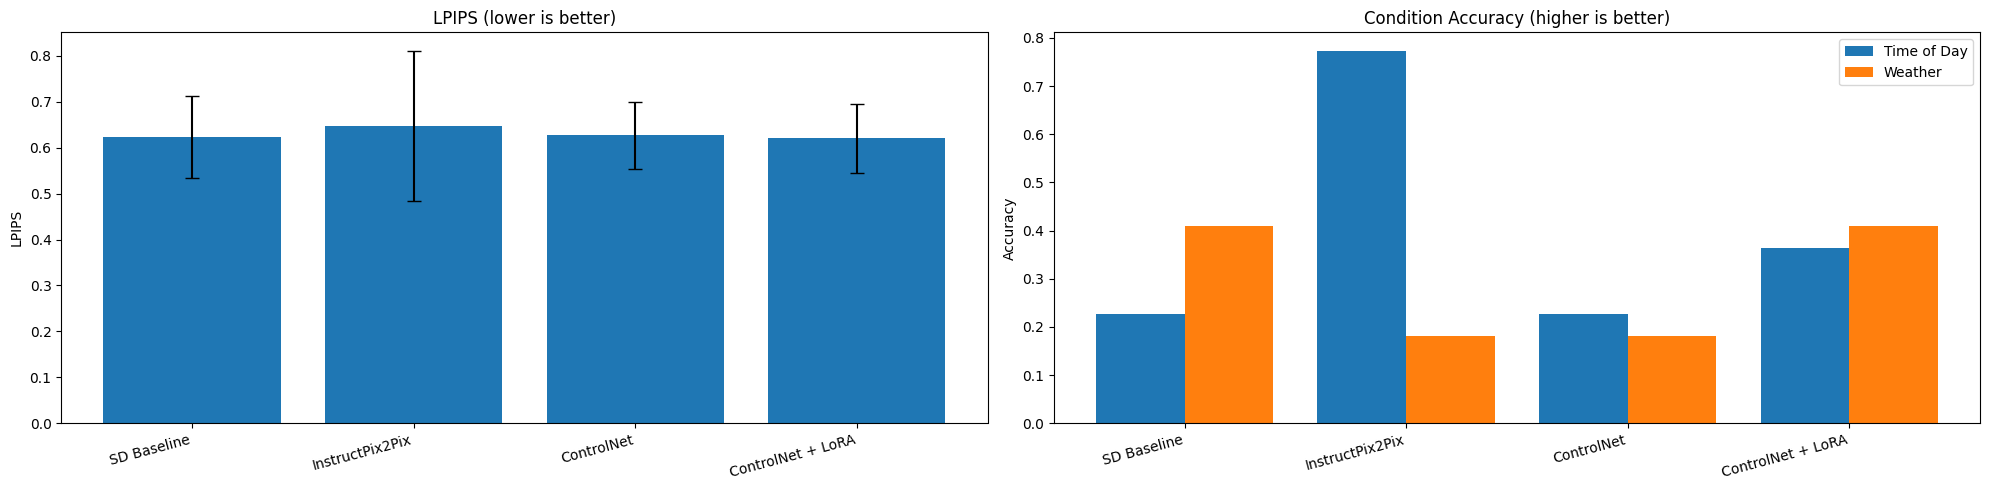

In [20]:
import matplotlib.pyplot as plt

n = len(results_df)
x = np.arange(n)
labels = results_df['Model']

fig, axes = plt.subplots(1, 2, figsize=(5 * n, 5))

axes[0].bar(x, results_df['LPIPS'], yerr=results_df['LPIPS std'], capsize=5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].set_title('LPIPS (lower is better)'); axes[0].set_ylabel('LPIPS')

axes[1].bar(x - 0.2, results_df['ToD Acc'],     width=0.4, label='Time of Day')
axes[1].bar(x + 0.2, results_df['Weather Acc'], width=0.4, label='Weather')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].set_title('Condition Accuracy (higher is better)')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
os.makedirs(f'{BASE}/outputs', exist_ok=True)
plt.savefig(f'{BASE}/outputs/evaluation_summary.png', dpi=150, bbox_inches='tight')
plt.show()